In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Create dummy dataset
np.random.seed(42)

luas = np.random.randint(
    30,
    200,
    1000
)

harga = (
    50 * luas
    + np.random.normal(
        0,
        500,
        1000
    )
)

In [7]:
df = pd.DataFrame({
    "luas": luas,
    "harga": harga
})

df.head()

,luas,harga
0,132,6769.248204
1,122,5892.356043
2,44,2516.390933
3,136,7935.346429
4,101,5140.933128


In [8]:
df.shape

(1000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   luas    1000 non-null   int64  
 1   harga   1000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


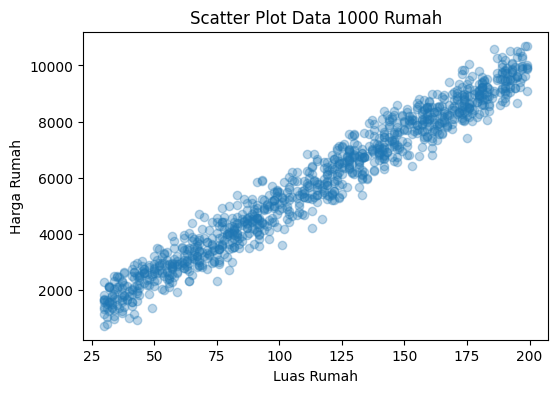

In [9]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["luas"],
    df["harga"],
    alpha=0.3
)

plt.xlabel("Luas Rumah")
plt.ylabel("Harga Rumah")
plt.title("Scatter Plot Data 1000 Rumah")

plt.show()

In [10]:
X = df["luas"]
y = df["harga"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [21]:
print(f"Data latih X {X_train.shape[0]}")
print(f"Data test X {X_test.shape[0]}")
print(f"Data latih y {y_train.shape[0]}")
print(f"Data test y {y_test.shape[0]}")

Data latih X 800
Data test X 200
Data latih y 800
Data test y 200


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train.values.reshape(-1,1), y_train)

LinearRegression()

In [24]:
y_pred = model.predict(
    X_test.values.reshape(-1, 1)
)

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [26]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 402.1426966886644
MSE : 254135.23239921595
RMSE: 504.1182722330306
R2  : 0.9599146582177372


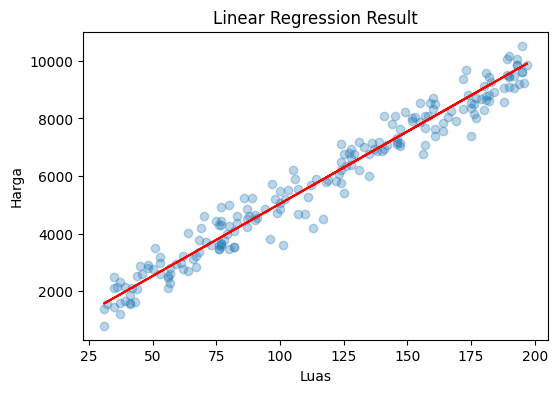

In [27]:
plt.figure(figsize=(6,4))

plt.scatter(X_test, y_test, alpha=0.3)

plt.plot(X_test, y_pred, color="red")

plt.title("Linear Regression Result")
plt.xlabel("Luas")
plt.ylabel("Harga")

plt.show()

In [28]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 50.14175173416638
Intercept: 27.7852869739545
